<a href="https://colab.research.google.com/github/alokchoudharyguliya/Transformers/blob/main/Automatic_Speech_Recognition_with_TF2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np,io,os,re,string
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer
from tensorflow.keras.layers import (
    Embedding,Input, LSTM, Conv2D, Softmax, Dropout, Dense, GRU,
    MaxPooling2D, LayerNormalization, Reshape, BatchNormalization, Bidirectional
)
from tensorflow.keras.optimizers import Adam

In [7]:
BATCH_SIZE=32
LR=1e-4
FRAME_LENGTH=225
FRAME_STEP=128
N_EPOCHS=100

# Everything Data

## Data Download

In [8]:
!wget https://data.keithito.com/data/speech/LJSpeech-1.1.tar.bz2

--2026-03-22 03:07:52--  https://data.keithito.com/data/speech/LJSpeech-1.1.tar.bz2
Resolving data.keithito.com (data.keithito.com)... 143.244.50.82, 2400:52e0:1a01::992:1
Connecting to data.keithito.com (data.keithito.com)|143.244.50.82|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2748572632 (2.6G) [text/plain]
Saving to: ‘LJSpeech-1.1.tar.bz2’

LJSpeech-1.1.tar.bz 100%[===================>]   2.56G  73.8MB/s    in 31s     

2026-03-22 03:08:23 (85.7 MB/s) - ‘LJSpeech-1.1.tar.bz2’ saved [2748572632/2748572632]



In [9]:
!mkdir "/content/dataset/"

In [10]:
!tar -xvjf "/content/LJSpeech-1.1.tar.bz2" -C "/content/dataset/"

Streaming output truncated to the last 5000 lines.
LJSpeech-1.1/wavs/LJ022-0089.wav
LJSpeech-1.1/wavs/LJ030-0192.wav
LJSpeech-1.1/wavs/LJ041-0078.wav
LJSpeech-1.1/wavs/LJ045-0249.wav
LJSpeech-1.1/wavs/LJ034-0035.wav
LJSpeech-1.1/wavs/LJ010-0152.wav
LJSpeech-1.1/wavs/LJ036-0174.wav
LJSpeech-1.1/wavs/LJ035-0076.wav
LJSpeech-1.1/wavs/LJ032-0176.wav
LJSpeech-1.1/wavs/LJ046-0113.wav
LJSpeech-1.1/wavs/LJ017-0096.wav
LJSpeech-1.1/wavs/LJ004-0098.wav
LJSpeech-1.1/wavs/LJ010-0147.wav
LJSpeech-1.1/wavs/LJ042-0230.wav
LJSpeech-1.1/wavs/LJ041-0033.wav
LJSpeech-1.1/wavs/LJ045-0229.wav
LJSpeech-1.1/wavs/LJ014-0199.wav
LJSpeech-1.1/wavs/LJ002-0082.wav
LJSpeech-1.1/wavs/LJ006-0055.wav
LJSpeech-1.1/wavs/LJ045-0120.wav
LJSpeech-1.1/wavs/LJ050-0028.wav
LJSpeech-1.1/wavs/LJ045-0215.wav
LJSpeech-1.1/wavs/LJ013-0121.wav
LJSpeech-1.1/wavs/LJ008-0025.wav
LJSpeech-1.1/wavs/LJ005-0240.wav
LJSpeech-1.1/wavs/LJ044-0026.wav
LJSpeech-1.1/wavs/LJ048-0127.wav
LJSpeech-1.1/wavs/LJ006-0195.wav
LJSpeech-1.1/wavs/LJ030-0

## Data Visualization

In [11]:
audio_binary=tf.io.read_file("/content/dataset/LJSpeech-1.1/wavs/LJ001-0001.wav")
audio,_=tf.audio.decode_wav(audio_binary)
waveform=tf.squeeze(audio,axis=-1)
waveform=tf.cast(waveform,tf.float32)
signal=waveform
print(signal.shape)

(212893,)


(212893,)


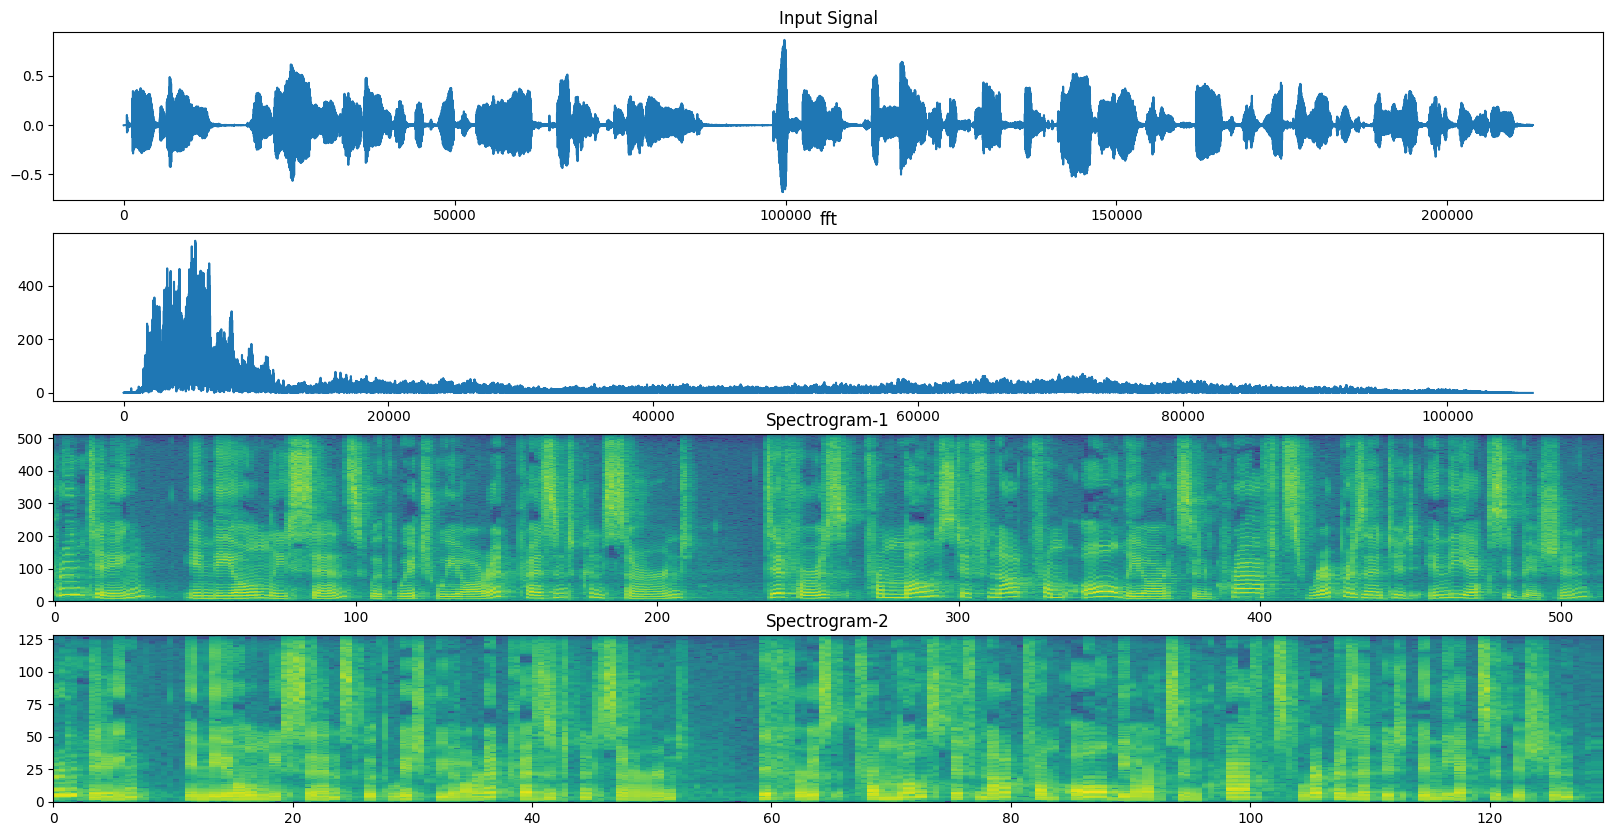

In [12]:
fig,axis=plt.subplots(4,figsize=(20,10))
L=2000
x=tf.linspace(-L//2,L//2,L)
print(signal.shape)
axis[0].plot(signal)
axis[0].set_title("Input Signal")
fft=tf.signal.rfft(signal)
axis[1].plot(tf.abs(fft))
axis[1].set_title("fft")
spec=tf.signal.stft(signal,frame_length=1024,frame_step=512,)
spec=tf.transpose(tf.abs(spec),[1,0])
power_spec=np.log(spec)
height=power_spec.shape[0]

width=power_spec.shape[1]
X=np.linspace(0,power_spec.shape[0],num=width,dtype=int)
Y=range(height)
axis[2].pcolormesh(X,Y,power_spec)
axis[2].set_title("Spectrogram-1")
spec=tf.signal.stft(signal,frame_length=256,frame_step=128,)
spec=tf.transpose(tf.abs(spec),[1,0])
power_spec=np.log(spec)
height=power_spec.shape[0]
width=power_spec.shape[1]
X=np.linspace(0,power_spec.shape[0],num=width,dtype=int)
Y=range(height)
axis[3].pcolormesh(X,Y,power_spec)
axis[3].set_title("Spectrogram-2")
plt.show()

## Data Preparation

In [13]:
audio_text={}
text_path="/content/dataset/LJSpeech-1.1/metadata.csv"
with open(text_path,encoding="utf-8") as f:
  for line in f:
    i=line.strip().split("|")[0]
    text=line.strip().split("|")[1]
    audio_text[str(i)]=text

In [14]:
audio_text

{'LJ001-0001': 'Printing, in the only sense with which we are at present concerned, differs from most if not from all the arts and crafts represented in the Exhibition',
 'LJ001-0002': 'in being comparatively modern.',
 'LJ001-0003': 'For although the Chinese took impressions from wood blocks engraved in relief for centuries before the woodcutters of the Netherlands, by a similar process',
 'LJ001-0004': 'produced the block books, which were the immediate predecessors of the true printed book,',
 'LJ001-0005': 'the invention of movable metal letters in the middle of the fifteenth century may justly be considered as the invention of the art of printing.',
 'LJ001-0006': 'And it is worth mention in passing that, as an example of fine typography,',
 'LJ001-0007': 'the earliest book printed with movable types, the Gutenberg, or "forty-two line Bible" of about 1455,',
 'LJ001-0008': 'has never been surpassed.',
 'LJ001-0009': 'Printing, then, for our purpose, may be considered as the art of

In [15]:
filepaths=["/content/dataset/LJSpeech"+filename+".wav" for filename in list(audio_text.keys())]
transcriptions=[audio_text[str(filename)].lower() for filename in list(audio_text.keys())]
print(len(filepaths))
print(len(transcriptions))

13100
13100


In [16]:
filepaths

['/content/dataset/LJSpeechLJ001-0001.wav',
 '/content/dataset/LJSpeechLJ001-0002.wav',
 '/content/dataset/LJSpeechLJ001-0003.wav',
 '/content/dataset/LJSpeechLJ001-0004.wav',
 '/content/dataset/LJSpeechLJ001-0005.wav',
 '/content/dataset/LJSpeechLJ001-0006.wav',
 '/content/dataset/LJSpeechLJ001-0007.wav',
 '/content/dataset/LJSpeechLJ001-0008.wav',
 '/content/dataset/LJSpeechLJ001-0009.wav',
 '/content/dataset/LJSpeechLJ001-0010.wav',
 '/content/dataset/LJSpeechLJ001-0011.wav',
 '/content/dataset/LJSpeechLJ001-0012.wav',
 '/content/dataset/LJSpeechLJ001-0013.wav',
 '/content/dataset/LJSpeechLJ001-0014.wav',
 '/content/dataset/LJSpeechLJ001-0015.wav',
 '/content/dataset/LJSpeechLJ001-0016.wav',
 '/content/dataset/LJSpeechLJ001-0017.wav',
 '/content/dataset/LJSpeechLJ001-0018.wav',
 '/content/dataset/LJSpeechLJ001-0019.wav',
 '/content/dataset/LJSpeechLJ001-0020.wav',
 '/content/dataset/LJSpeechLJ001-0021.wav',
 '/content/dataset/LJSpeechLJ001-0022.wav',
 '/content/dataset/LJSpeechLJ001

In [17]:
dataset=tf.data.Dataset.from_tensor_slices((filepaths,transcriptions))

In [18]:
for i in dataset.take(1):
  print(i)

(<tf.Tensor: shape=(), dtype=string, numpy=b'/content/dataset/LJSpeechLJ001-0001.wav'>, <tf.Tensor: shape=(), dtype=string, numpy=b'printing, in the only sense with which we are at present concerned, differs from most if not from all the arts and crafts represented in the exhibition'>)


In [19]:
def decode_audio(audio_library):
  audio,_=tf.audio.decode_wav(audio_binary)
  return tf.squeeze(audio,axis=-1)

In [20]:
vocabulary=[""]+[chr(i) for i in range(97,97+26)]+[".",","," ","?"]
print(vocabulary)
print(len(vocabulary))

['', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '.', ',', ' ', '?']
31


In [21]:
def get_label(label,):
  label=tf.strings.unicode_split(label,input_encoding="UTF-8")
  label=tf.keras.layers.StringLookup(vocabulary=vocabulary, oov_token="")(label)
  return label

In [22]:
def get_spec(filepath,label):
  audio_binary=tf.io.read_file(filepath)
  waveform=decode_audio(audio_binary)
  waveform=tf.cast(waveform,tf.float32)
  spectogram=tf.signal.stft(waveform,frame_length=FRAME_LENGTH, frame_step=FRAME_STEP)
  spectogram=tf.abs(spectogram)
  label=get_label(label)
  return tf.expand_dims(spectogram,axis=-1),label

In [23]:
processed_dataset=(
    dataset.map(get_spec,num_parallel_calls=tf.data.AUTOTUNE).padded_batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)
)

In [24]:
train_dataset=processed_dataset.take(int(0.95*len(processed_dataset)))
val_dataset=processed_dataset.skip(int(0.95*len(processed_dataset)))

In [25]:
for i,j in train_dataset.take(1):
  print(i,j)

tf.Tensor(
[[[[7.34692730e-05]
   [3.81777575e-03]
   [3.92847601e-03]
   ...
   [1.18796917e-04]
   [9.24941560e-05]
   [3.63785366e-05]]

  [[5.63959684e-03]
   [6.27651205e-03]
   [6.68411236e-03]
   ...
   [1.01615442e-04]
   [6.43162202e-05]
   [3.76494136e-05]]

  [[9.69166588e-03]
   [2.37879576e-03]
   [1.06152305e-02]
   ...
   [1.53617017e-04]
   [6.82800646e-06]
   [1.03876926e-04]]

  ...

  [[5.72846457e-03]
   [1.24277538e-02]
   [3.18640247e-02]
   ...
   [5.37264023e-05]
   [4.38784373e-05]
   [2.81762332e-05]]

  [[3.44486651e-03]
   [5.52972453e-03]
   [2.64992565e-02]
   ...
   [8.12488361e-05]
   [1.13590999e-04]
   [6.44137617e-05]]

  [[8.51431489e-03]
   [5.17208641e-03]
   [8.05599522e-03]
   ...
   [2.02983283e-04]
   [1.81850410e-04]
   [1.15429051e-04]]]


 [[[7.34692730e-05]
   [3.81777575e-03]
   [3.92847601e-03]
   ...
   [1.18796917e-04]
   [9.24941560e-05]
   [3.63785366e-05]]

  [[5.63959684e-03]
   [6.27651205e-03]
   [6.68411236e-03]
   ...
   [1.0161

# Modelling and Training
Deepspeech 2 = https://arxiv.org/pdf/1512.02595


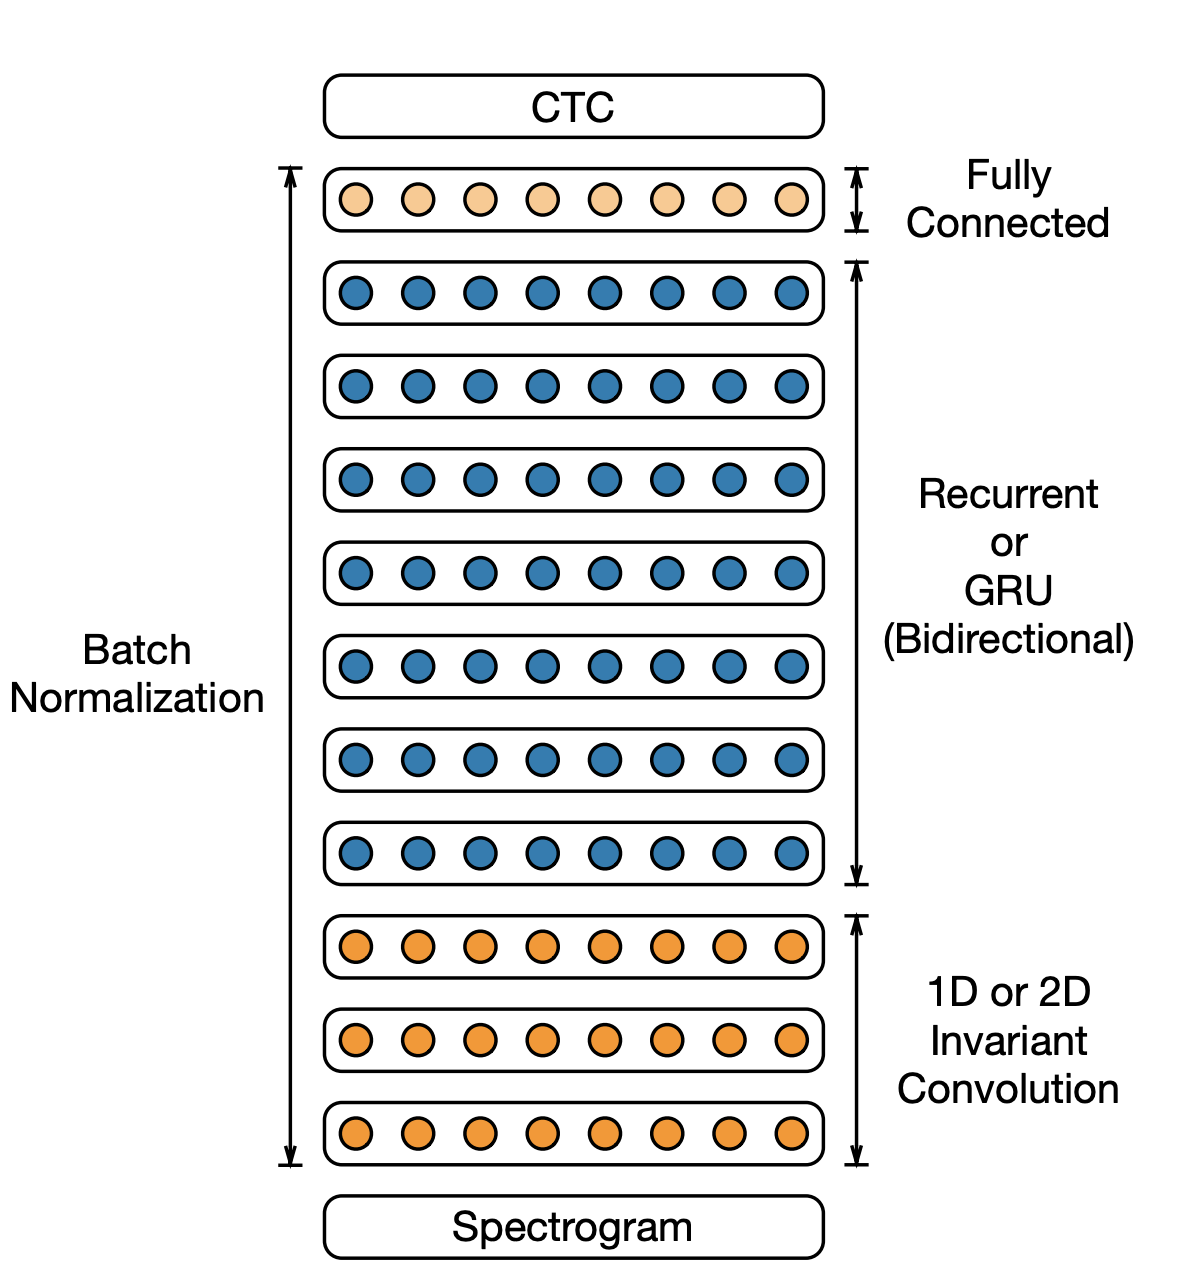

In [26]:
normalization=tf.keras.layers.Normalization()
input_spectogram=Input((None, 129,1),name="input")

x=normalization(input_spectogram)
x=Conv2D(32,kernel_size=[11,41],strides=[2,2],padding='same',activation='relu')(x)
x=LayerNormalization()(x)
x=Conv2D(64,kernel_size=[11,21],strides=[1,2],padding='same',activation='relu')(x)
x=LayerNormalization()(x)
x=Reshape((-1,x.shape[-2]*x.shape[-1]))(x)
x=Bidirectional(GRU(128,return_sequences=True))(x)
x=Bidirectional(GRU(128,return_sequences=True))(x)
x=Bidirectional(GRU(128,return_sequences=True))(x)

output=Dense(len(vocabulary)+1,activation="softmax")(x)
model=tf.keras.Model(input_spectogram,output,name="DeepSpeech_2_Inspired")
model.summary()

Model: "DeepSpeech_2_Inspired"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, None, 129, 1)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, None, 129, 1)   │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, None, 65, 32)   │        14,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, None, 65, 32)   │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, None, 33, 64)   │       473,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, None, 33, 64)   │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, None, 2112)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, None, 256)      │     1,721,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, None, 256)      │       296,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, None, 256)      │       296,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 32)       │         8,224 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,810,787 (10.72 MB)

 Trainable params: 2,810,784 (10.72 MB)

 Non-trainable params: 3 (16.00 B)

In [30]:
def ctc_loss(y_true, y_pred):
  batch_size=tf.shape(y_pred)[0]
  pred_length=tf.shape(y_pred)[1]
  true_length=tf.shape(y_true)[1]
  pred_length=pred_length*tf.ones([batch_size,1],dtype=tf.int32)
  true_length=true_length*tf.ones([batch_size,1],dtype=tf.int32)
  return tf.keras.backend.ctc_batch_cost(y_true,y_pred,pred_length,true_length)

In [31]:
model.compile(loss=ctc_loss, optimizer=tf.keras.optimizers.Adam(learning_rate=LR))

In [ ]:
history=model.fit(train_dataset,validation_data=val_dataset,verbose=1,epochs=N_EPOCHS)

Epoch 1/100
 14/389 ━━━━━━━━━━━━━━━━━━━━ 11:40 2s/step - loss: 1007.0314

In [47]:
model.load_weights("/content/drive/MyDrive/nlp/ctc_keras.h5")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/drive/MyDrive/nlp/ctc_keras.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
history=model.fit(train_dataset,validation_data=val_dataset,verbose=1,epochs=N_EPOCHS)

# Testing

In [4]:
def get_spec_inference(filepath):
  audio_binary=tf.io.read_file(filepath)
  waveform=decode_audio(audio_binary)
  waveform=tf.cast(waveform,tf.float32)
  spectogram=tf.signal.stft(waveform,frame_length=FRAME_LENGTH,frame_step=FRAME_STEP)
  spectrogram=tf.asb(spectogram)
  return tf.expand_dims(spectogram,axis=-1)

In [5]:
test_path="/content/"

In [3]:
spectogram=get_spec_inference(test_path)
print(spectogram.shape)
out=tf.argmax(model.predict(tf.expand_dims(spectogram,axis=0))[0],axis=1)

NameError: name 'get_spec_inference' is not defined

In [ ]:
out_list=[vocabulary[i] if i!=31 else "[LINK]" for i in out]
out_str="".join(out_list)

In [ ]:
print(out_str)

In [ ]:
def decode(y_pred):
  batch_size=tf.shape(y_pred)[0]
  print(tf.shape(y_pred))
  pred_length=tf.shape(y_pred)[1]
  pred_length=tf.ones([batch_size,],dtype=tf.int32)
  y_pred=tf.one_hot(y_pred,len(vocabulary)+1)
  output=tf.keras.backend.ctc_decode(y_pred,input_length=pred_length,greedy=True)[0][0]
  out=[vocabulary[i] for i output[0]]
  return "".join(out)

In [ ]:
print(decode(tf.expand_dims(out,axis=0)))